# Project Title
# Supply Chain Management Demand Forecasting & Operational Analysis

## Problem Statement
Efficient supply chain planning depends on accurate demand estimation and a clear understanding of operational drivers such as stock position, production volume, shipping cost, inspection quality, lead time, and transportation decisions.

This project builds an end-to-end supply chain notebook that:
- explores operational patterns in the dataset,
- identifies business bottlenecks and performance drivers,
- prepares clean analytical data,
- trains machine learning models to predict **HistoricalSales**,
- compares model quality using business-relevant error metrics,
- explains key features driving demand predictions.


### Step 1 — Data Collection & Environment Setup

### Objective
The objective of this step is to gather relevant supply chain data from reliable sources and prepare a structured dataset for analysis. It also involves setting up the required programming environment, libraries, and tools to ensure smooth data processing, visualization, and model development throughout the project.

### Purpose
A stable project begins with a clean, reproducible environment. This step ensures that all libraries required for analysis, visualization, preprocessing, modeling, and model export are available before any transformation starts.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

### Step 2 — Data Loading and Dataset Integration

#### Objective: The objective of this step is to load the collected supply chain data into the analysis environment and integrate it into a unified, structured format. This ensures that all relevant data sources are properly combined and ready for preprocessing and analysis.

#### Purpose:
The purpose is to create a consistent and reliable dataset by merging and organizing data from different sources, enabling accurate analysis, feature engineering, and model building in subsequent steps.

In [2]:
file_path = "supply_chain_data.csv"
df = pd.read_csv(file_path)

raw_df = df.copy()

In [3]:
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
print("Shape:", df.shape)

Shape: (200, 31)


In [5]:
df.head()

,ProductID,Date,HistoricalSales,Price,Availability,Stock_levels,Order_quantities,Shipping_times,Shipping_costs,Supplier_name,Location,Lead_times,Lead_time,Production_volumes,Manufacturing_lead_time,Manufacturing_costs,Inspection_results,Defect_rates,Transportation_modes,Routes,Costs,Promotion,Weather,EconomicIndicators,Month_No,Day_Of_Week,Quarter_No,Day_No,Inventory_Pressure,Cost_per_Unit_Sold,Lead_Time_Gap
0,SKU0,2023-01-01,802,69.81,55,58,96,4,2.96,Supplier 3,Mumbai,7,29,215,29,46.28,Pending,0.23,Road,Route B,187.75,Yes,Normal,Stable_Environment,1,1,1,1,1.63,0.23,22
1,SKU1,2023-01-03,736,14.84,95,53,37,2,9.72,Supplier 3,Mumbai,30,23,517,30,33.62,Pending,4.85,Road,Route B,503.07,No,Normal,Stable_Environment,1,3,1,3,0.69,0.68,0
2,SKU2,2023-01-25,8,11.32,34,1,88,2,8.05,Supplier 1,Mumbai,10,12,971,27,30.69,Pending,4.58,Air,Route C,141.92,No,Normal,Stable_Environment,1,4,1,25,44.00,15.77,17
3,SKU3,2023-02-16,83,61.16,68,23,59,6,1.73,Supplier 5,Kolkata,13,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78,Yes,Adverse,Stable_Environment,2,5,1,16,2.46,3.03,5
4,SKU4,2023-03-10,871,4.81,26,5,56,8,3.89,Supplier 1,Delhi,3,5,414,3,92.07,Fail,3.15,Air,Route A,923.44,No,Adverse,High_Cost_Environment,3,6,1,10,9.33,1.06,0


### Step 3 — Dataset Understanding

#### Objective: To inspect the dataset structure, data types, null values, duplicates, and the initial business readiness of the records.

#### Purpose
Before analysis or modeling, it is essential to verify whether the data is complete, whether any duplicate entries exist, and whether date and category fields are in a usable format. This prevents misleading patterns later in the notebook.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ProductID                200 non-null    object 
 1   Date                     200 non-null    object 
 2   HistoricalSales          200 non-null    int64  
 3   Price                    200 non-null    float64
 4   Availability             200 non-null    int64  
 5   Stock_levels             200 non-null    int64  
 6   Order_quantities         200 non-null    int64  
 7   Shipping_times           200 non-null    int64  
 8   Shipping_costs           200 non-null    float64
 9   Supplier_name            200 non-null    object 
 10  Location                 200 non-null    object 
 11  Lead_times               200 non-null    int64  
 12  Lead_time                200 non-null    int64  
 13  Production_volumes       200 non-null    int64  
 14  Manufacturing_lead_time  2

In [7]:
df.columns.tolist()

['ProductID',
 'Date',
 'HistoricalSales',
 'Price',
 'Availability',
 'Stock_levels',
 'Order_quantities',
 'Shipping_times',
 'Shipping_costs',
 'Supplier_name',
 'Location',
 'Lead_times',
 'Lead_time',
 'Production_volumes',
 'Manufacturing_lead_time',
 'Manufacturing_costs',
 'Inspection_results',
 'Defect_rates',
 'Transportation_modes',
 'Routes',
 'Costs',
 'Promotion',
 'Weather',
 'EconomicIndicators',
 'Month_No',
 'Day_Of_Week',
 'Quarter_No',
 'Day_No',
 'Inventory_Pressure',
 'Cost_per_Unit_Sold',
 'Lead_Time_Gap']

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ProductID,200,100,SKU0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,200,100,2023-01-01,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HistoricalSales,200.00,NaN,NaN,NaN,460.99,303.02,8.00,184.25,392.50,704.25,996.00
Price,200.00,NaN,NaN,NaN,49.46,31.09,1.70,19.59,51.24,77.19,99.17
Availability,200.00,NaN,NaN,NaN,48.40,30.67,1.00,22.75,43.50,75.00,100.00
Stock_levels,200.00,NaN,NaN,NaN,47.77,31.29,0.00,16.75,47.50,73.00,100.00
Order_quantities,200.00,NaN,NaN,NaN,49.22,26.72,1.00,26.00,52.00,71.25,96.00
Shipping_times,200.00,NaN,NaN,NaN,5.75,2.72,1.00,3.75,6.00,8.00,10.00
Shipping_costs,200.00,NaN,NaN,NaN,5.55,2.65,1.01,3.54,5.32,7.60,9.93
Supplier_name,200,5,Supplier 1,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
null_summary = df.isnull().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print("Total missing values:", int(null_summary.sum()))
print("Duplicate rows:", int(duplicate_count))

null_summary[null_summary > 0]

Total missing values: 0
Duplicate rows: 100


Series([], dtype: int64)

### Initial Understanding Insight

- The dataset contains a mix of **numerical, categorical, and date-like** fields suitable for both analytics and demand prediction.
- Missing values are not a major issue in this dataset, but duplicate rows must be handled carefully because they can distort sales, cost, and forecast results.
- The target variable for the machine learning workflow will be **HistoricalSales**.

### Step 4 — Data Cleaning & Preparation

#### Objective: To clean duplicate records, convert the date column, and build foundational calendar features required for analysis and forecasting.

#### Purpose
High-quality modeling depends on trustworthy data. This step removes repeated rows, standardizes date information, and creates useful fields such as month name, day of week, and quarter that support business analysis and machine learning.

In [10]:
df = df.drop_duplicates().copy()

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

In [12]:
df["Year"] = df["Date"].dt.year

In [13]:
df["Month"] = df["Date"].dt.month

In [14]:
df["Month_Name"] = df["Date"].dt.month_name()

In [15]:
df["Day"] = df["Date"].dt.day

In [16]:
df["DayOfWeek"] = df["Date"].dt.day_name()

In [17]:
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)

In [18]:
df["Revenue_Estimate"] = df["HistoricalSales"] * df["Price"]

In [19]:
df["Stock_to_Order_Ratio"] = df["Stock_levels"] / (df["Order_quantities"] + 1)

In [20]:
df["Production_to_Sales_Ratio"] = df["Production_volumes"] / (df["HistoricalSales"] + 1)

In [21]:
df["Inventory_Gap"] = df["Stock_levels"] - df["Order_quantities"]

In [22]:
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (100, 41)


In [23]:
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

Date range: 2023-01-01 to 2023-07-18


In [24]:
df.head()

,ProductID,Date,HistoricalSales,Price,Availability,Stock_levels,Order_quantities,Shipping_times,Shipping_costs,Supplier_name,Location,Lead_times,Lead_time,Production_volumes,Manufacturing_lead_time,Manufacturing_costs,Inspection_results,Defect_rates,Transportation_modes,Routes,Costs,Promotion,Weather,EconomicIndicators,Month_No,Day_Of_Week,Quarter_No,Day_No,Inventory_Pressure,Cost_per_Unit_Sold,Lead_Time_Gap,Year,Month,Month_Name,Day,DayOfWeek,WeekOfYear,Revenue_Estimate,Stock_to_Order_Ratio,Production_to_Sales_Ratio,Inventory_Gap
0,SKU0,2023-01-01,802,69.81,55,58,96,4,2.96,Supplier 3,Mumbai,7,29,215,29,46.28,Pending,0.23,Road,Route B,187.75,Yes,Normal,Stable_Environment,1,1,1,1,1.63,0.23,22,2023,1,January,1,Sunday,52,"55,987.62",0.60,0.27,-38
1,SKU1,2023-01-03,736,14.84,95,53,37,2,9.72,Supplier 3,Mumbai,30,23,517,30,33.62,Pending,4.85,Road,Route B,503.07,No,Normal,Stable_Environment,1,3,1,3,0.69,0.68,0,2023,1,January,3,Tuesday,1,"10,922.24",1.39,0.70,16
2,SKU2,2023-01-25,8,11.32,34,1,88,2,8.05,Supplier 1,Mumbai,10,12,971,27,30.69,Pending,4.58,Air,Route C,141.92,No,Normal,Stable_Environment,1,4,1,25,44.00,15.77,17,2023,1,January,25,Wednesday,4,90.56,0.01,107.89,-87
3,SKU3,2023-02-16,83,61.16,68,23,59,6,1.73,Supplier 5,Kolkata,13,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78,Yes,Adverse,Stable_Environment,2,5,1,16,2.46,3.03,5,2023,2,February,16,Thursday,7,"5,076.28",0.38,11.15,-36
4,SKU4,2023-03-10,871,4.81,26,5,56,8,3.89,Supplier 1,Delhi,3,5,414,3,92.07,Fail,3.15,Air,Route A,923.44,No,Adverse,High_Cost_Environment,3,6,1,10,9.33,1.06,0,2023,3,March,10,Friday,10,"4,189.51",0.09,0.47,-51


# Key Business Questions

1. How does historical demand evolve over time?  
2. Which suppliers and locations contribute the most to supply chain value?  
3. How do transportation, inspection outcomes, and operational costs vary across the business?  
4. Which operational variables are most associated with demand?  
5. How accurately can machine learning models predict **HistoricalSales**?  
6. What operational levers appear most important for forecasting future demand?

### Step 5 — Exploratory Data Analysis (EDA)

#### Objective: To analyze sales, revenue, supplier performance, logistics cost, inspection results, and demand behavior using visual and numerical exploration.

#### Purpose
EDA helps convert raw transactions into business understanding. It highlights patterns, imbalances, and relationships that support better operational decisions and better feature engineering for machine learning.

In [25]:
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

#### 5.1 Demand Distribution Across Product 

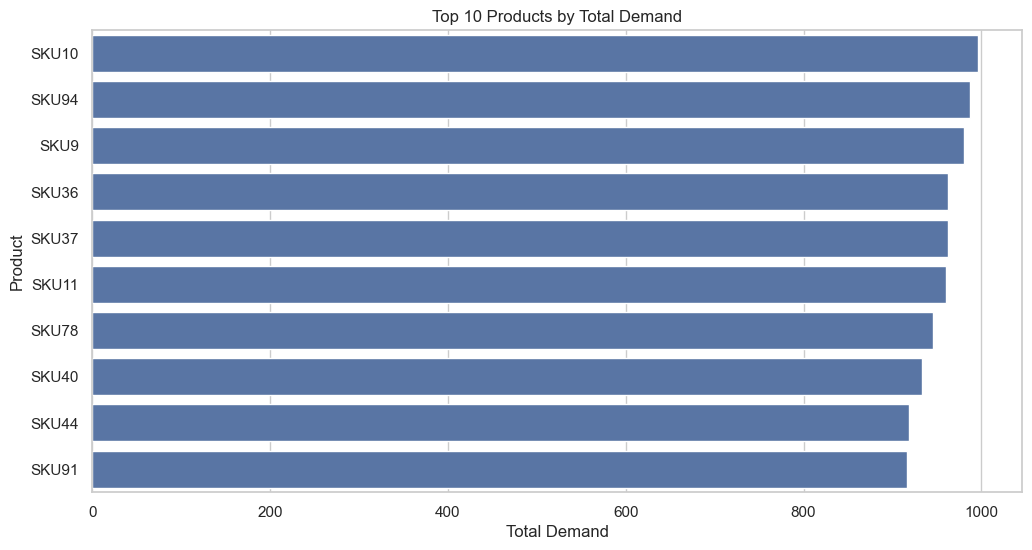

In [26]:
product_col = "ProductID"
demand_col = "HistoricalSales"

product_demand_summary = (
    df[[product_col, demand_col]]
    .dropna()
    .assign(HistoricalSales=lambda x: pd.to_numeric(x[demand_col], errors="coerce"))
    .dropna(subset=[demand_col])
    .groupby(product_col)[demand_col]
    .sum()
    .reset_index()
    .sort_values(by=demand_col, ascending=False)
)

top_10_products = product_demand_summary.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_products, x=demand_col, y=product_col)
plt.title("Top 10 Products by Total Demand")
plt.xlabel("Total Demand")
plt.ylabel("Product")
plt.show()

#### Insight:

The chart shows that demand is highly concentrated among a few top products (SKUs), with SKU10, SKU94, and SKU9 leading in total demand. This indicates that a small number of products contribute significantly to overall demand.

#### 5.2 Historical Sales Trend Over Time

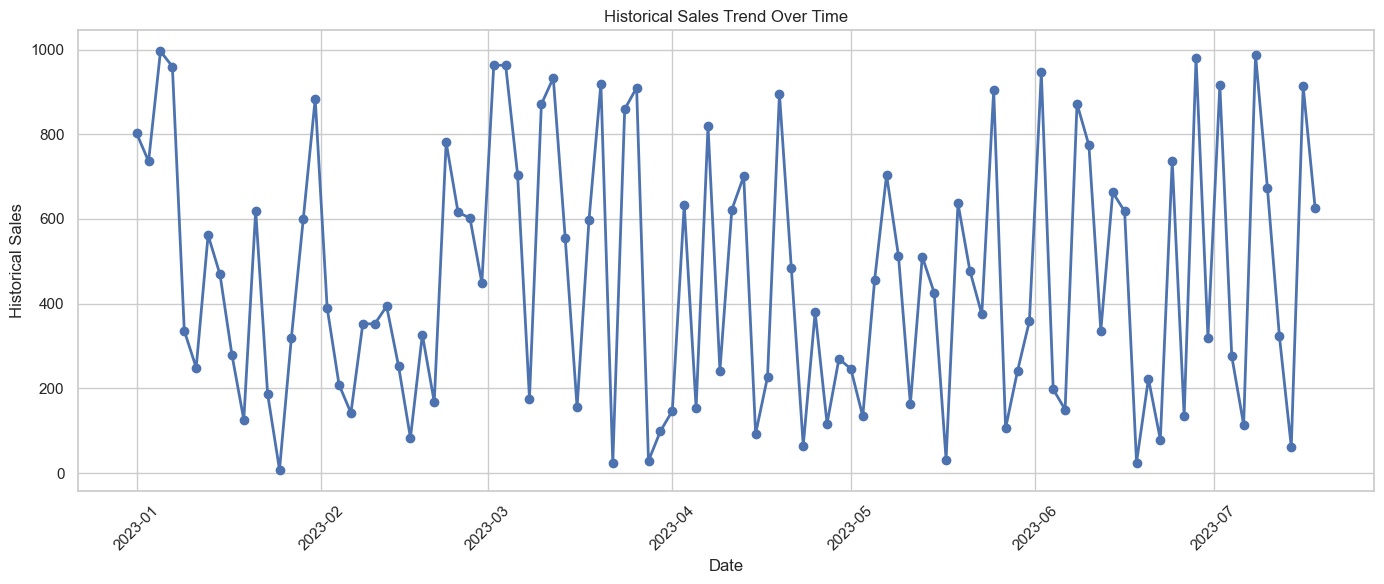

In [27]:
sales_trend = df.sort_values("Date")[["Date", "HistoricalSales"]]

plt.figure(figsize=(14, 6))
plt.plot(sales_trend["Date"], sales_trend["HistoricalSales"], marker="o", linewidth=2)
plt.title("Historical Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Historical Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**  
The historical sales trend shows high volatility with frequent spikes and drops, indicating inconsistent demand patterns over time. There is no clear upward or downward trend, suggesting that sales are influenced by external factors such as seasonality, promotions, or supply fluctuations rather than steady growth.

#### 5.3 Monthly Sales Distribution

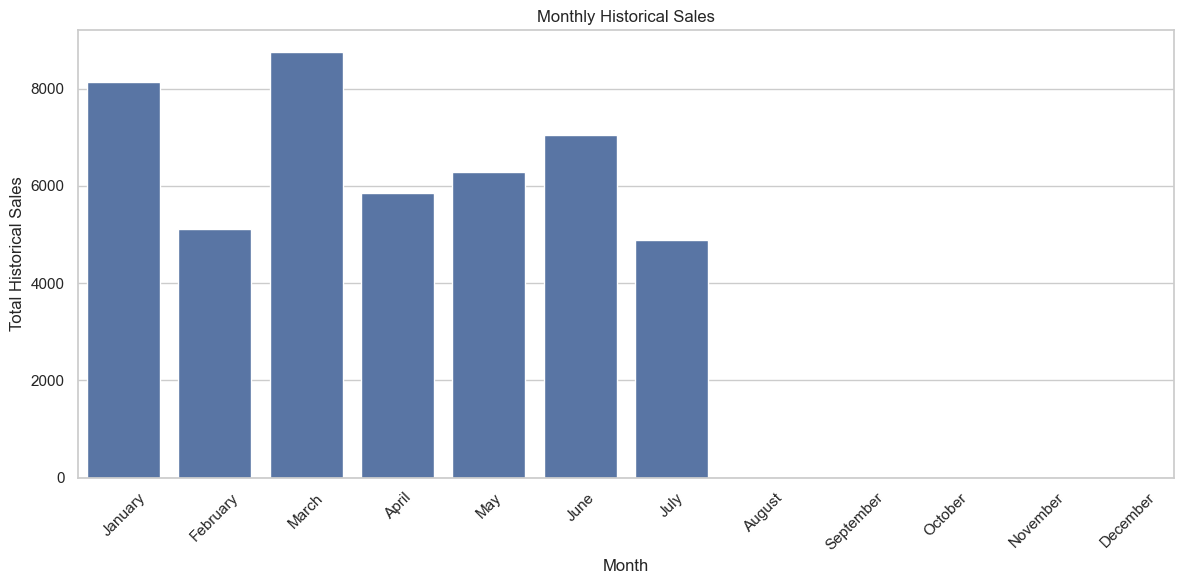

In [28]:
monthly_sales = (
    df.groupby("Month_Name", as_index=False)["HistoricalSales"]
      .sum()
)

month_order = ["January", "February", "March", "April", "May", "June", "July",
               "August", "September", "October", "November", "December"]

monthly_sales["Month_Name"] = pd.Categorical(monthly_sales["Month_Name"], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values("Month_Name")

plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_sales, x="Month_Name", y="HistoricalSales")
plt.title("Monthly Historical Sales")
plt.xlabel("Month")
plt.ylabel("Total Historical Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**  
Monthly sales show a clear fluctuation pattern, with March recording the highest sales, indicating a peak demand period, while February and July show relatively lower performance. This suggests possible seasonality in demand, where certain months consistently perform better, helping businesses plan inventory and promotions more effectively.

#### 5.4 Supplier-wise Sales Performance

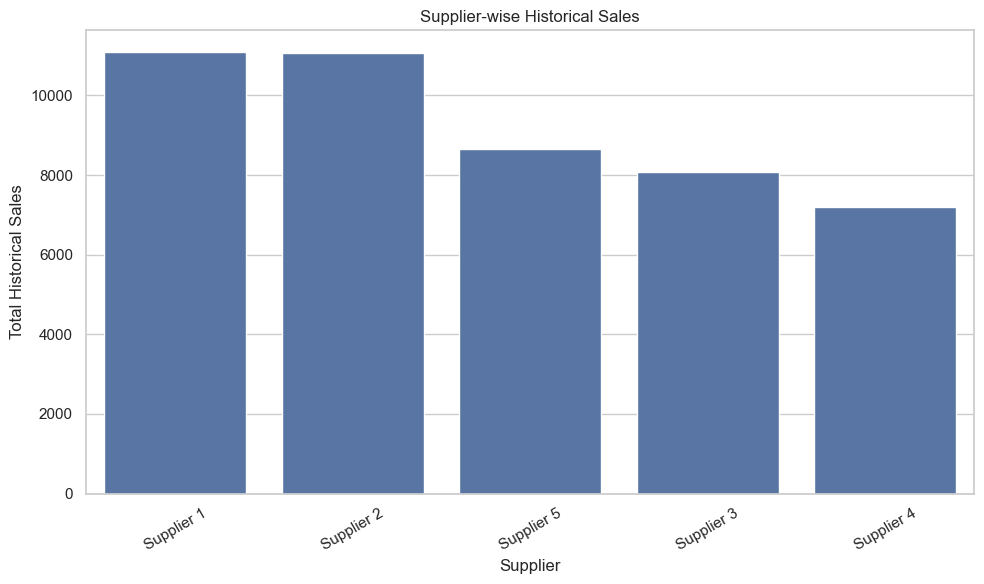

In [29]:
supplier_sales = (
    df.groupby("Supplier_name", as_index=False)["HistoricalSales"]
      .sum()
      .sort_values("HistoricalSales", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=supplier_sales, x="Supplier_name", y="HistoricalSales")
plt.title("Supplier-wise Historical Sales")
plt.xlabel("Supplier")
plt.ylabel("Total Historical Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



**Insight:**  
Supplier performance is clearly concentrated among the top two, with Supplier 1 (11,080) and Supplier 2 (11,068) generating nearly equal and highest sales, indicating strong and consistent contribution. Meanwhile, Supplier 4 (7,206) shows the lowest performance, suggesting a gap that could be improved through better sourcing strategies or performance optimization.

In [30]:
supplier_sales

,Supplier_name,HistoricalSales
0,Supplier 1,11080
1,Supplier 2,11068
4,Supplier 5,8662
2,Supplier 3,8083
3,Supplier 4,7206


#### 5.5 Location-wise Estimated Revenue

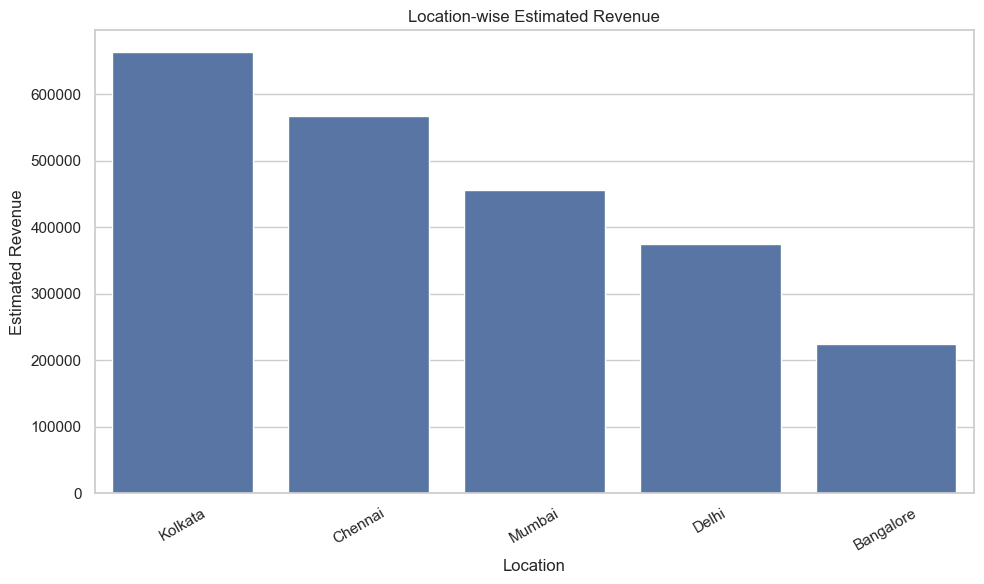

In [31]:
location_revenue = (
    df.groupby("Location", as_index=False)["Revenue_Estimate"]
      .sum()
      .sort_values("Revenue_Estimate", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=location_revenue, x="Location", y="Revenue_Estimate")
plt.title("Location-wise Estimated Revenue")
plt.xlabel("Location")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



**Insight:**  
Revenue distribution across locations shows that Kolkata generates the highest estimated revenue, followed by Chennai and Mumbai, indicating strong market performance in these regions. In contrast, Bangalore records the lowest revenue, suggesting weaker demand or market penetration, highlighting an opportunity for targeted growth strategies.

In [32]:
location_revenue

,Location,Revenue_Estimate
3,Kolkata,"662,566.55"
1,Chennai,"567,604.98"
4,Mumbai,"455,535.20"
2,Delhi,"375,037.94"
0,Bangalore,"224,810.86"


#### 5.6 Shipping Cost by Transportation Mode

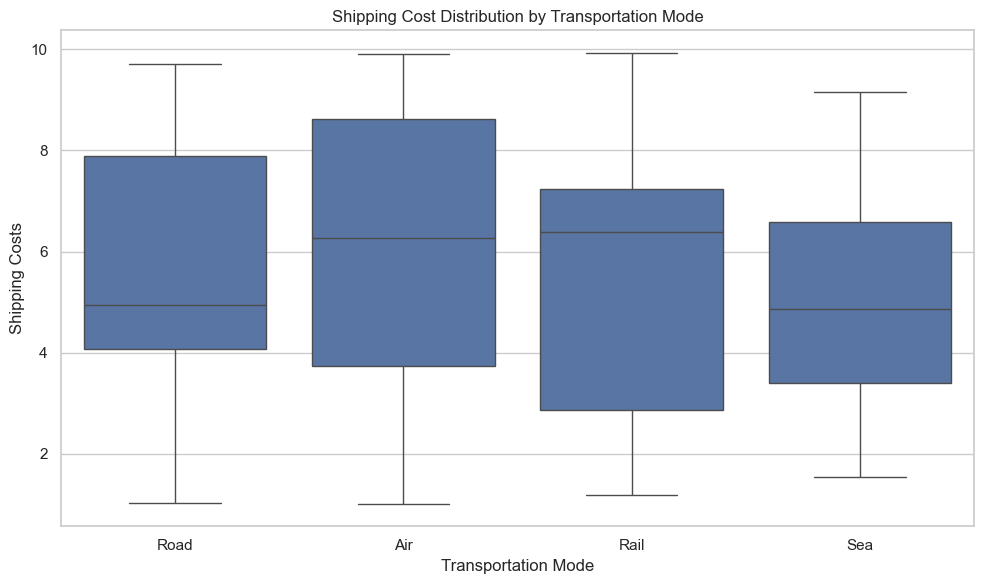

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Transportation_modes", y="Shipping_costs")
plt.title("Shipping Cost Distribution by Transportation Mode")
plt.xlabel("Transportation Mode")
plt.ylabel("Shipping Costs")
plt.tight_layout()
plt.show()

**Insight:**  
Shipping cost distribution varies significantly across transportation modes, with Air transport showing the highest median cost and greatest variability, indicating higher expense and less predictability. In contrast, Road and Sea transport have relatively moderate and more stable costs, making them more cost-efficient options for non-urgent deliveries, while Rail shows a balanced cost profile.

#### 5.7 Manufacturing Cost vs Price

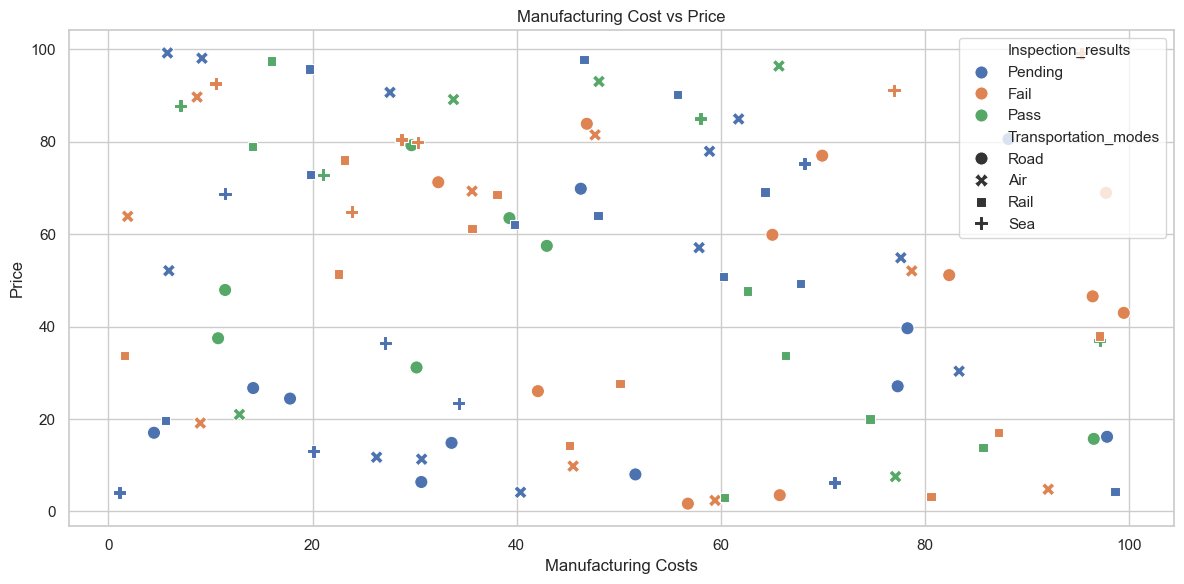

In [34]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Manufacturing_costs",
    y="Price",
    hue="Inspection_results",
    style="Transportation_modes",
    s=90
)
plt.title("Manufacturing Cost vs Price")
plt.xlabel("Manufacturing Costs")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

**Insight:**  
Manufacturing cost and price show a weak correlation, indicating pricing is not solely driven by production cost.
Other factors like quality inspection results, transportation mode, and market dynamics significantly influence final pricing.

#### 5.8 Defect Rates by Inspection Result

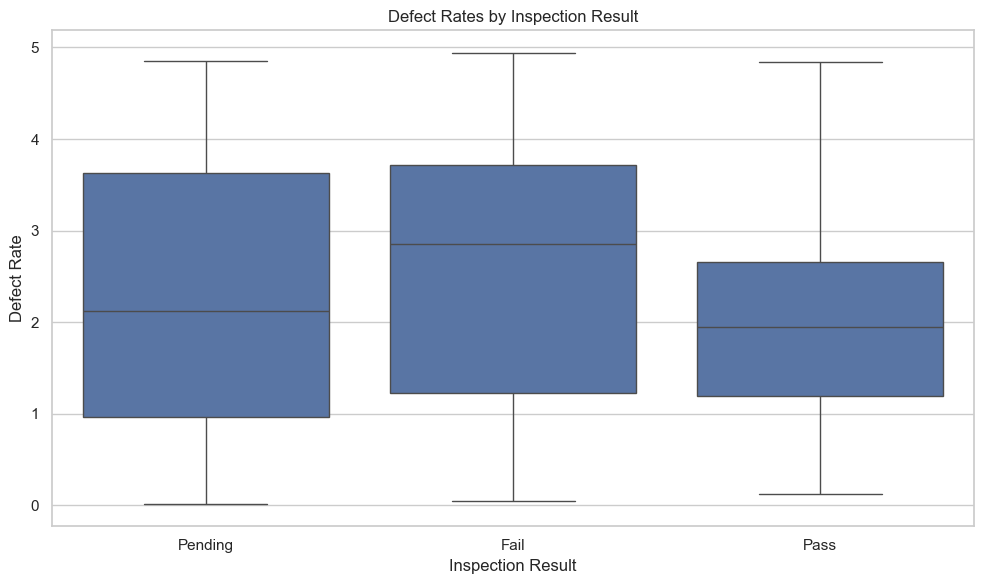

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Inspection_results", y="Defect_rates")
plt.title("Defect Rates by Inspection Result")
plt.xlabel("Inspection Result")
plt.ylabel("Defect Rate")
plt.tight_layout()
plt.show()

**Insight:**  
Defect rates are highest for failed inspections, indicating quality issues significantly impact product rejection.
In contrast, passed inspections show lower and more consistent defect rates, reflecting better quality control and process efficiency.

#### 5.9 Stock Levels vs Order Quantities

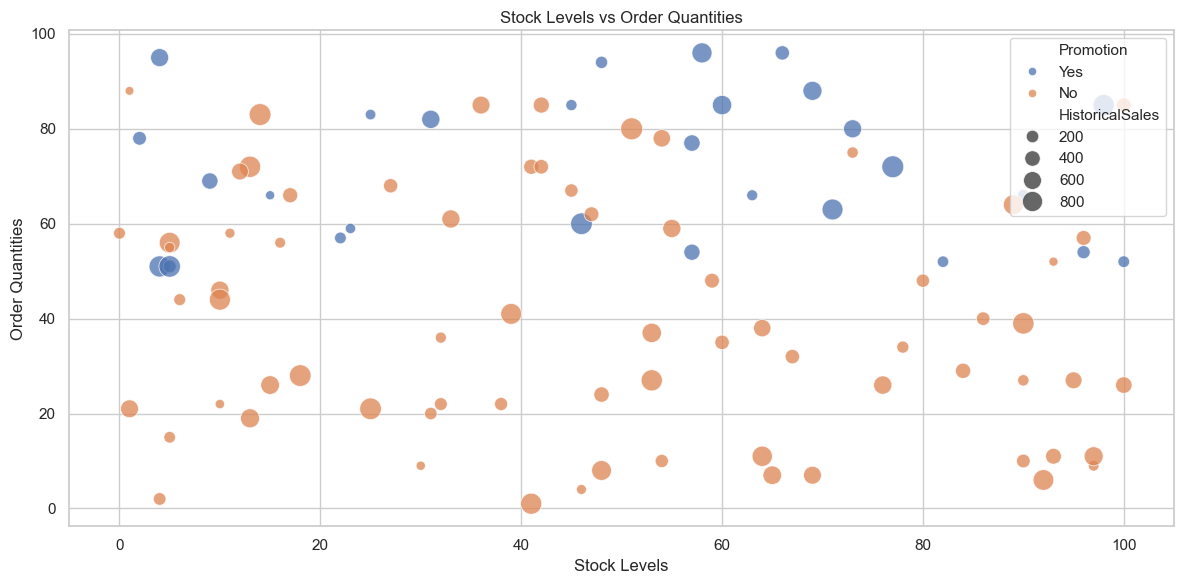

In [36]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Stock_levels",
    y="Order_quantities",
    hue="Promotion",
    size="HistoricalSales",
    sizes=(40, 250),
    alpha=0.75
)
plt.title("Stock Levels vs Order Quantities")
plt.xlabel("Stock Levels")
plt.ylabel("Order Quantities")
plt.tight_layout()
plt.show()

**Insight:**  
Stock levels and order quantities show a weak relationship, indicating demand is not solely dependent on available inventory.
Higher order quantities are often observed during promotions, suggesting promotions significantly drive demand regardless of stock levels.

#### 5.10 Correlation Heatmap of Numerical Variables

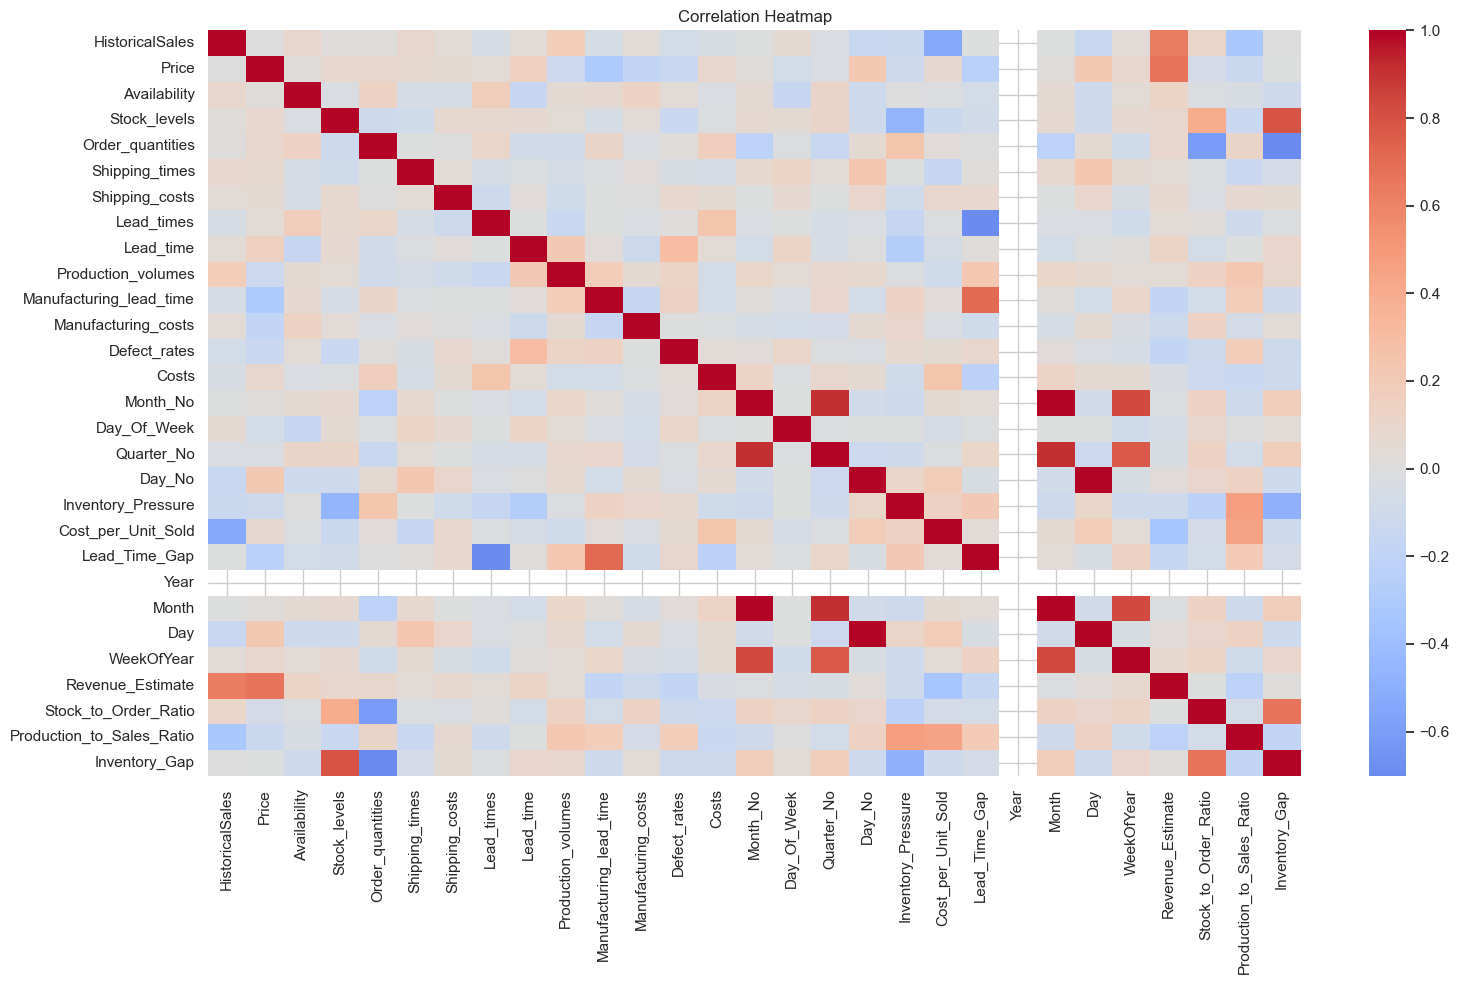

In [37]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16, 10))
corr = num_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Insight:**  
Most features show weak to moderate correlations, indicating that no single factor strongly drives overall performance.
However, time-related features and derived ratios exhibit stronger relationships, suggesting temporal patterns and engineered features play a key role in demand and supply behavior.

### EDA Summary

The exploratory analysis reveals that the supply chain data exhibits high variability in sales and demand, with no consistent trend over time. Seasonal patterns are visible, with certain months and locations contributing more to overall revenue. Supplier analysis shows that a few suppliers dominate performance, while others lag behind, indicating opportunities for optimization. Additionally, shipping costs vary significantly across transportation modes, with air being the most expensive and road/sea more cost-efficient.

Further analysis indicates weak relationships between key variables such as manufacturing cost and price, as well as stock levels and order quantities, suggesting that demand and pricing are influenced by multiple external factors like promotions and market conditions. Defect rates are higher in failed inspections, emphasizing the importance of quality control. Overall, the dataset highlights a complex system where time-based and derived features play a crucial role in understanding and improving supply chain performance.

### Step 6 — Time Series Data Preparation

#### Objective: To transform the supply chain dataset into a structured time-series format that represents product demand trends over time. This prepared dataset will support trend analysis, forecasting, and machine learning models for predicting future demand.

#### Purpose:
Currently, the dataset contains sales-related features such as ProductID, HistoricalSales, Price, Promotion, Weather, and EconomicIndicators. However, without proper time-series formatting, the model cannot clearly learn trend-based behavior, seasonality, or recent demand movement.

Therefore, we convert the Date column into datetime format, sort the records in chronological order, and aggregate demand at a useful time level. We also create moving average values to smooth short-term fluctuations and highlight the long-term demand pattern.

In [38]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [39]:
df = df.dropna(subset=["Date"]).copy()

In [40]:
df = df.sort_values(["ProductID", "Date"]).reset_index(drop=True)

In [41]:
df.head()

,ProductID,Date,HistoricalSales,Price,Availability,Stock_levels,Order_quantities,Shipping_times,Shipping_costs,Supplier_name,Location,Lead_times,Lead_time,Production_volumes,Manufacturing_lead_time,Manufacturing_costs,Inspection_results,Defect_rates,Transportation_modes,Routes,Costs,Promotion,Weather,EconomicIndicators,Month_No,Day_Of_Week,Quarter_No,Day_No,Inventory_Pressure,Cost_per_Unit_Sold,Lead_Time_Gap,Year,Month,Month_Name,Day,DayOfWeek,WeekOfYear,Revenue_Estimate,Stock_to_Order_Ratio,Production_to_Sales_Ratio,Inventory_Gap
0,SKU0,2023-01-01,802,69.81,55,58,96,4,2.96,Supplier 3,Mumbai,7,29,215,29,46.28,Pending,0.23,Road,Route B,187.75,Yes,Normal,Stable_Environment,1,1,1,1,1.63,0.23,22,2023,1,January,1,Sunday,52,"55,987.62",0.60,0.27,-38
1,SKU1,2023-01-03,736,14.84,95,53,37,2,9.72,Supplier 3,Mumbai,30,23,517,30,33.62,Pending,4.85,Road,Route B,503.07,No,Normal,Stable_Environment,1,3,1,3,0.69,0.68,0,2023,1,January,3,Tuesday,1,"10,922.24",1.39,0.70,16
2,SKU10,2023-01-05,996,15.71,11,51,80,2,8.67,Supplier 5,Kolkata,13,18,830,5,96.53,Pass,1.73,Road,Route B,806.10,No,Normal,High_Cost_Environment,1,5,1,5,1.54,0.81,-8,2023,1,January,5,Thursday,1,"15,647.16",0.63,0.83,-29
3,SKU11,2023-01-07,960,90.64,95,46,60,1,4.52,Supplier 2,Kolkata,23,28,362,11,27.59,Pending,0.02,Air,Route A,126.72,Yes,Normal,Stable_Environment,1,7,1,7,1.28,0.13,-12,2023,1,January,7,Saturday,1,"87,014.40",0.75,0.38,-14
4,SKU12,2023-01-09,336,71.21,41,100,85,4,1.33,Supplier 4,Kolkata,30,3,563,3,32.32,Fail,2.16,Road,Route B,402.97,No,Normal,Stable_Environment,1,2,1,9,0.84,1.20,-27,2023,1,January,9,Monday,2,"23,926.56",1.16,1.67,15


In [42]:
df_monthly_sales = df.resample("M", on="Date")["HistoricalSales"].sum().reset_index()

In [43]:
df_monthly_sales.columns = ["Date", "Sales"]

In [44]:
df_monthly_sales.head()

,Date,Sales
0,2023-01-31,8136
1,2023-02-28,5120
2,2023-03-31,8760
3,2023-04-30,5851
4,2023-05-31,6286


In [45]:
df_monthly_sales.shape

(7, 2)

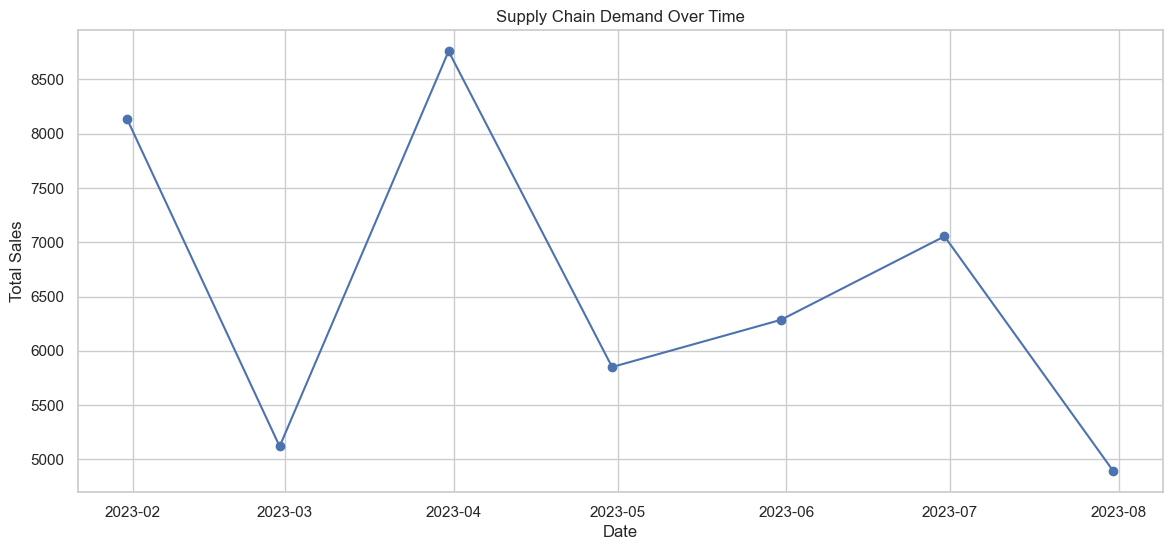

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df_monthly_sales["Date"], df_monthly_sales["Sales"], marker="o")
plt.title("Supply Chain Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

#### Insight:
The demand trend shows noticeable fluctuations across months, indicating unstable sales patterns influenced by external factors such as promotions, pricing, or supply constraints. A peak is observed around April, followed by a decline and moderate recovery, suggesting short-term demand variability rather than consistent growth.

In [47]:
df_monthly_sales["Moving_Avg_12"] = df_monthly_sales["Sales"].rolling(window=12).mean()

df_monthly_sales.head()

,Date,Sales,Moving_Avg_12
0,2023-01-31,8136,NaN
1,2023-02-28,5120,NaN
2,2023-03-31,8760,NaN
3,2023-04-30,5851,NaN
4,2023-05-31,6286,NaN


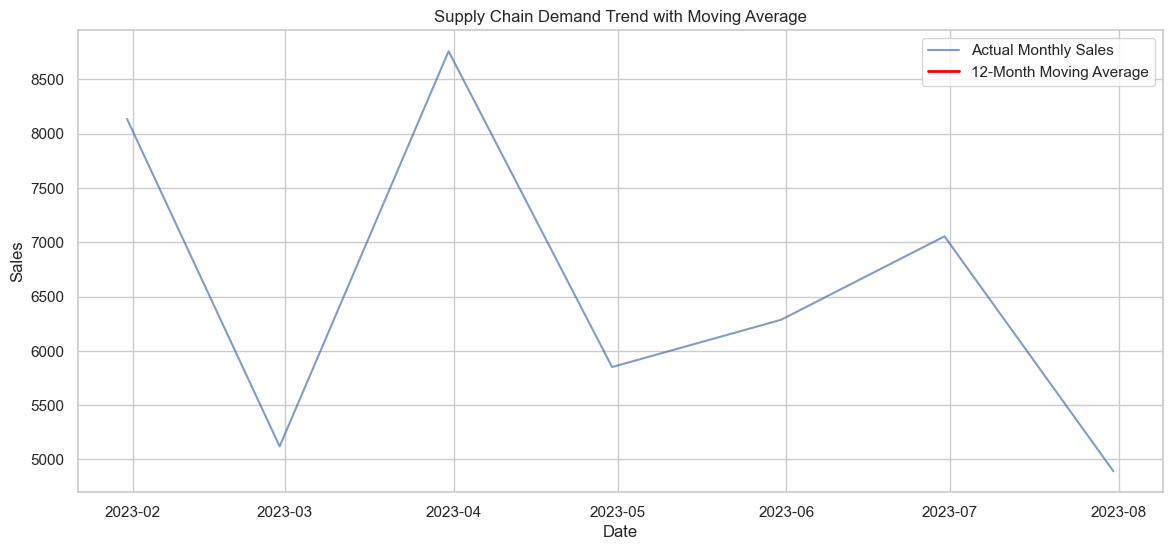

In [48]:
plt.figure(figsize=(14, 6))

# Original sales trend
plt.plot(
    df_monthly_sales["Date"],
    df_monthly_sales["Sales"],
    label="Actual Monthly Sales",
    alpha=0.7
)

# Moving average line
plt.plot(
    df_monthly_sales["Date"],
    df_monthly_sales["Moving_Avg_12"],
    label="12-Month Moving Average",
    color="red",
    linewidth=2
)

plt.title("Supply Chain Demand Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

#### Insight:
While actual sales exhibit sharp fluctuations, the moving average reveals the true demand direction by reducing noise. The trend suggests a temporary growth phase followed by a slowdown, indicating that demand is not consistently stable and requires forecasting models that can capture both short-term variability and long-term patterns.

### Step 7 — Feature Engineering for Machine Learning

#### Objective: To prepare model-ready features from operational, categorical, and calendar data for demand prediction.

#### Purpose
Machine learning models work best when business information is converted into structured predictors. This step builds the final feature set, encodes cyclical calendar behavior, and prepares the dataset for chronological train-test splitting.

In [49]:
ml_df = df.copy().sort_values("Date").reset_index(drop=True)

In [50]:
ml_df["Month_sin"] = np.sin(2 * np.pi * ml_df["Month"] / 12)

In [51]:
ml_df["Month_cos"] = np.cos(2 * np.pi * ml_df["Month"] / 12)

In [52]:
ml_df["Cost_to_Price_Ratio"] = ml_df["Manufacturing_costs"] / (ml_df["Price"] + 1)

In [53]:
ml_df["Shipping_to_Cost_Ratio"] = ml_df["Shipping_costs"] / (ml_df["Costs"] + 1)

In [54]:
ml_df["Sales_per_Stock"] = ml_df["HistoricalSales"] / (ml_df["Stock_levels"] + 1)

In [55]:
ml_df.head()

,ProductID,Date,HistoricalSales,Price,Availability,Stock_levels,Order_quantities,Shipping_times,Shipping_costs,Supplier_name,Location,Lead_times,Lead_time,Production_volumes,Manufacturing_lead_time,Manufacturing_costs,Inspection_results,Defect_rates,Transportation_modes,Routes,Costs,Promotion,Weather,EconomicIndicators,Month_No,Day_Of_Week,Quarter_No,Day_No,Inventory_Pressure,Cost_per_Unit_Sold,Lead_Time_Gap,Year,Month,Month_Name,Day,DayOfWeek,WeekOfYear,Revenue_Estimate,Stock_to_Order_Ratio,Production_to_Sales_Ratio,Inventory_Gap,Month_sin,Month_cos,Cost_to_Price_Ratio,Shipping_to_Cost_Ratio,Sales_per_Stock
0,SKU0,2023-01-01,802,69.81,55,58,96,4,2.96,Supplier 3,Mumbai,7,29,215,29,46.28,Pending,0.23,Road,Route B,187.75,Yes,Normal,Stable_Environment,1,1,1,1,1.63,0.23,22,2023,1,January,1,Sunday,52,"55,987.62",0.60,0.27,-38,0.50,0.87,0.65,0.02,13.59
1,SKU1,2023-01-03,736,14.84,95,53,37,2,9.72,Supplier 3,Mumbai,30,23,517,30,33.62,Pending,4.85,Road,Route B,503.07,No,Normal,Stable_Environment,1,3,1,3,0.69,0.68,0,2023,1,January,3,Tuesday,1,"10,922.24",1.39,0.70,16,0.50,0.87,2.12,0.02,13.63
2,SKU10,2023-01-05,996,15.71,11,51,80,2,8.67,Supplier 5,Kolkata,13,18,830,5,96.53,Pass,1.73,Road,Route B,806.10,No,Normal,High_Cost_Environment,1,5,1,5,1.54,0.81,-8,2023,1,January,5,Thursday,1,"15,647.16",0.63,0.83,-29,0.50,0.87,5.78,0.01,19.15
3,SKU11,2023-01-07,960,90.64,95,46,60,1,4.52,Supplier 2,Kolkata,23,28,362,11,27.59,Pending,0.02,Air,Route A,126.72,Yes,Normal,Stable_Environment,1,7,1,7,1.28,0.13,-12,2023,1,January,7,Saturday,1,"87,014.40",0.75,0.38,-14,0.50,0.87,0.30,0.04,20.43
4,SKU12,2023-01-09,336,71.21,41,100,85,4,1.33,Supplier 4,Kolkata,30,3,563,3,32.32,Fail,2.16,Road,Route B,402.97,No,Normal,Stable_Environment,1,2,1,9,0.84,1.20,-27,2023,1,January,9,Monday,2,"23,926.56",1.16,1.67,15,0.50,0.87,0.45,0.00,3.33


In [56]:
target = "HistoricalSales"

drop_columns = ["HistoricalSales", "ProductID", "Date"]
X = ml_df.drop(columns=drop_columns)
y = ml_df[target]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = [col for col in X.columns if col not in categorical_cols]

In [57]:
print("Target:", target)

Target: HistoricalSales


In [58]:
print("Categorical columns:", categorical_cols)

Categorical columns: ['Supplier_name', 'Location', 'Inspection_results', 'Transportation_modes', 'Routes', 'Promotion', 'Weather', 'EconomicIndicators', 'Month_Name', 'DayOfWeek']


In [59]:
print("Numerical columns:", len(numerical_cols))

Numerical columns: 33


### Feature Engineering Insight

The final feature space combines:
- supply-side metrics such as stock, production, manufacturing cost, lead time, and shipping cost,
- quality and logistics categories such as inspection result, transport mode, and route,
- calendar behavior through month and cyclical month encoding,
- business ratios that make the model more sensitive to operational efficiency.

### Step 8 — Train-Test Split Strategy

#### Objective: To split the dataset chronologically so that the model learns from earlier records and is evaluated on later records.

#### Purpose
For forecasting-oriented business problems, preserving time order is more realistic than random splitting. It avoids information leakage and better reflects how a live prediction system would perform on future demand.

In [60]:
split_index = int(len(ml_df) * 0.80)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

train_dates = ml_df.loc[:split_index-1, "Date"]
test_dates = ml_df.loc[split_index:, "Date"]

In [61]:
print("Training rows:", X_train.shape[0])

Training rows: 80


In [62]:
print("Testing rows:", X_test.shape[0])

Testing rows: 20


In [63]:
print("Training date range:", train_dates.min().date(), "to", train_dates.max().date())

Training date range: 2023-01-01 to 2023-06-08


In [64]:
print("Testing date range:", test_dates.min().date(), "to", test_dates.max().date())

Testing date range: 2023-06-10 to 2023-07-18


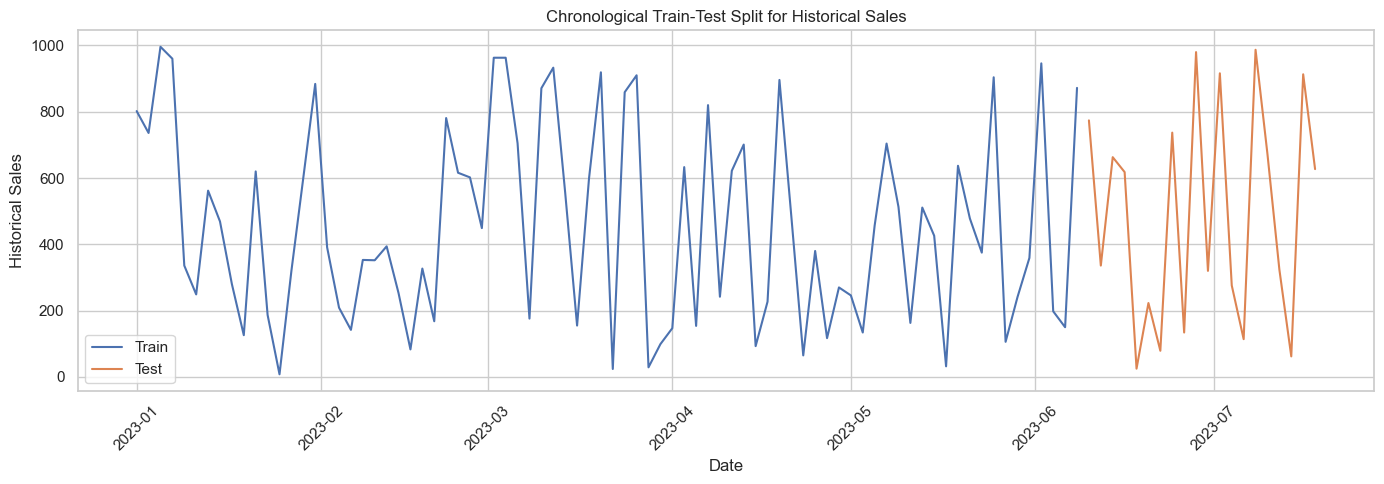

In [65]:
plt.figure(figsize=(14, 5))
plt.plot(ml_df["Date"].iloc[:split_index], y_train, label="Train")
plt.plot(ml_df["Date"].iloc[split_index:], y_test, label="Test")
plt.title("Chronological Train-Test Split for Historical Sales")
plt.xlabel("Date")
plt.ylabel("Historical Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Insight:**  
The chronological train-test split ensures that earlier data is used for training while recent data is reserved for testing, maintaining real-world forecasting conditions.
This approach helps evaluate how well the model generalizes to future demand patterns, making predictions more reliable and practical.

### Step 9 — Preprocessing Pipeline

#### Objective: To automate missing-value handling, scaling of numerical variables, and encoding of categorical variables in a reusable modeling pipeline.

#### Purpose
A preprocessing pipeline improves project quality by ensuring that the exact same transformation logic is applied during training, testing, and future prediction.

In [66]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Step 10 — Model Training

#### Objective: To train multiple machine learning models and compare their ability to predict historical demand.

#### Purpose
No single algorithm is always best. Comparing several strong regression models helps identify which one learns the supply chain patterns most effectively for this dataset.

In [67]:
fitted_models = {}
predictions = {}
results = []

In [68]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

fitted_models["Random Forest"] = rf_pipeline
predictions["Random Forest"] = rf_pred

mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100
r2 = r2_score(y_test, rf_pred)

results.append(["Random Forest", mae, rmse, mape, r2])

In [69]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

fitted_models["Gradient Boosting"] = gb_pipeline
predictions["Gradient Boosting"] = gb_pred

mae = mean_absolute_error(y_test, gb_pred)
rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
mape = np.mean(np.abs((y_test - gb_pred) / y_test)) * 100
r2 = r2_score(y_test, gb_pred)

results.append(["Gradient Boosting", mae, rmse, mape, r2])

In [70]:
et_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=300,
        max_depth=12,
        random_state=42
    ))
])

et_pipeline.fit(X_train, y_train)
et_pred = et_pipeline.predict(X_test)

fitted_models["Extra Trees"] = et_pipeline
predictions["Extra Trees"] = et_pred

mae = mean_absolute_error(y_test, et_pred)
rmse = np.sqrt(mean_squared_error(y_test, et_pred))
mape = np.mean(np.abs((y_test - et_pred) / y_test)) * 100
r2 = r2_score(y_test, et_pred)

results.append(["Extra Trees", mae, rmse, mape, r2])

In [71]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "MAPE", "R2"])
results_df = results_df.sort_values("RMSE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,MAPE,R2
0,Gradient Boosting,82.60,92.42,31.15,0.92
1,Random Forest,110.03,133.21,42.37,0.83
2,Extra Trees,114.56,149.12,60.79,0.79


### Model Training Insight

The Gradient Boosting model outperforms all others, achieving the lowest MAE, RMSE, and MAPE along with the highest R² (0.92), indicating strong predictive accuracy and reliability.
In comparison, Random Forest and Extra Trees show higher errors and lower R², suggesting they are less effective for this dataset, making Gradient Boosting the best choice for demand forecasting.

### Step 11 — Model Evaluation

#### Objective: To compare the prediction quality of the trained models and visualize how closely predictions align with actual demand.

#### Purpose
Evaluation makes the modeling section meaningful for business use. A model is only valuable if it predicts future demand with manageable error and follows the true movement of sales.

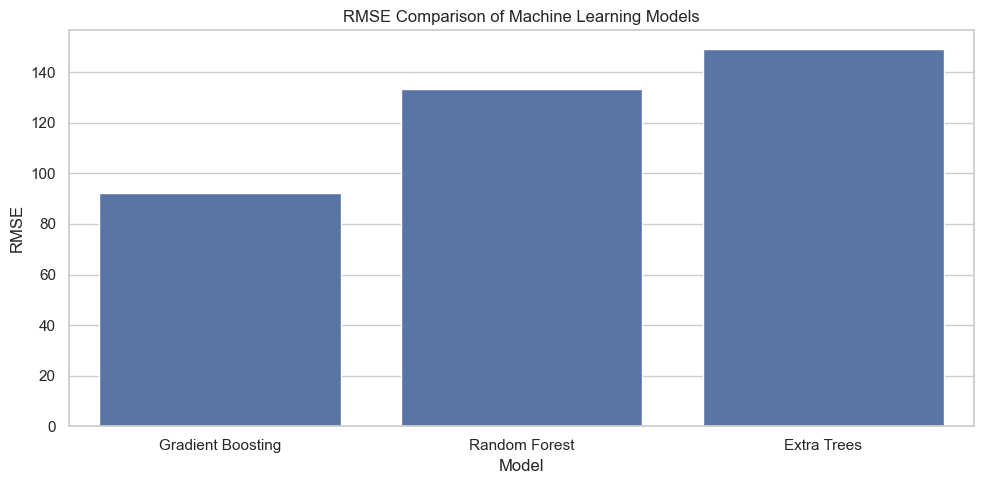

In [72]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("RMSE Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

**Insight**: 

The RMSE comparison clearly shows that Gradient Boosting has the lowest error, indicating the most accurate predictions among all models.
In contrast, Extra Trees has the highest RMSE, suggesting lower prediction reliability, while Random Forest performs moderately in between.

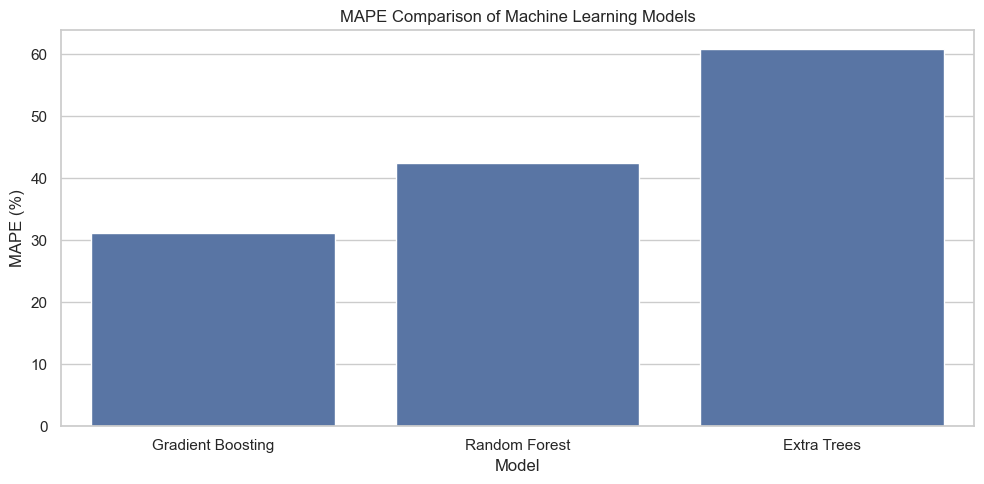

In [73]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="MAPE")
plt.title("MAPE Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.tight_layout()
plt.show()

**Insight:**

The MAPE comparison shows that Gradient Boosting has the lowest percentage error, making it the most accurate model in predicting demand.
In contrast, Extra Trees exhibits the highest MAPE, indicating less reliable predictions, while Random Forest performs moderately between the two.

In [74]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_pred = predictions[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: Gradient Boosting


**Insight:**  
The best model is selected using objective error metrics rather than assumption. Lower RMSE indicates better closeness to actual demand, while lower MAPE makes the result easier to interpret from a business perspective.

#### 11.1 Actual vs Predicted Sales

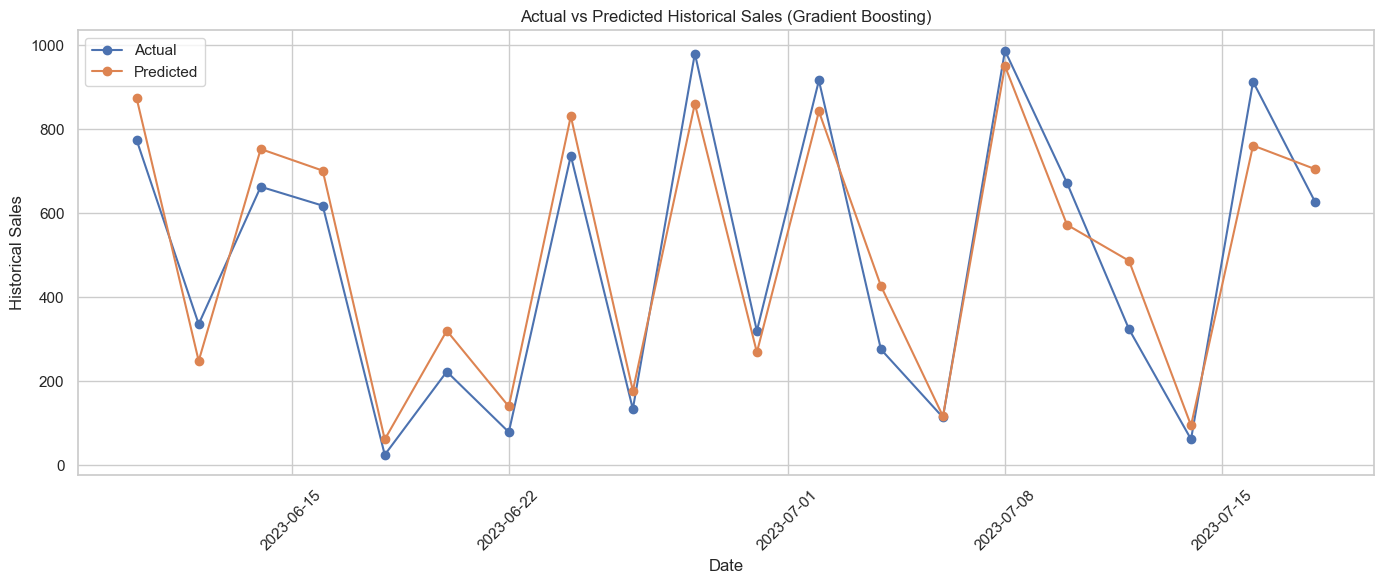

In [75]:
comparison_df = pd.DataFrame({
    "Date": test_dates.values,
    "ActualSales": y_test.values,
    "PredictedSales": best_pred
})

plt.figure(figsize=(14, 6))
plt.plot(comparison_df["Date"], comparison_df["ActualSales"], marker="o", label="Actual")
plt.plot(comparison_df["Date"], comparison_df["PredictedSales"], marker="o", label="Predicted")
plt.title(f"Actual vs Predicted Historical Sales ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Historical Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()



**Insight:**  
The predicted sales closely follow the actual sales trend, indicating that the Gradient Boosting model captures demand patterns effectively.
However, slight deviations at peak and low points suggest minor prediction errors, especially during sudden fluctuations in sales.

In [76]:
comparison_df.head()

,Date,ActualSales,PredictedSales
0,2023-06-10,774,873.29
1,2023-06-12,336,248.50
2,2023-06-14,663,752.80
3,2023-06-16,618,701.33
4,2023-06-18,25,61.70


#### 11.2 Residual Error Analysis

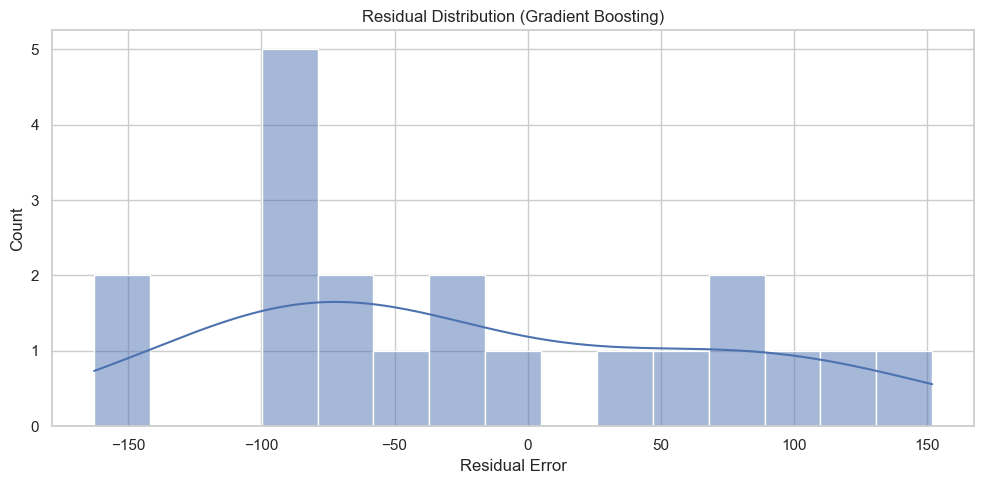

In [77]:
comparison_df["Residual"] = comparison_df["ActualSales"] - comparison_df["PredictedSales"]

plt.figure(figsize=(10, 5))
sns.histplot(comparison_df["Residual"], bins=15, kde=True)
plt.title(f"Residual Distribution ({best_model_name})")
plt.xlabel("Residual Error")
plt.tight_layout()
plt.show()

**Insight:**  
The residuals are mostly centered around zero, indicating that the model’s predictions are generally unbiased and well-balanced.
However, the spread of residuals suggests some errors in extreme cases, meaning the model slightly struggles with high volatility or sudden demand changes.

### Step 12 — Feature Importance Analysis

#### Objective: To identify which features most strongly influence predicted historical sales.

### Purpose
Feature importance improves model interpretability. It helps explain which operational variables planners should monitor most closely when demand changes.

In [78]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

In [79]:
importance_values = best_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values("Importance", ascending=False)


In [80]:
feature_importance_df.head(15)

,Feature,Importance
18,num__Cost_per_Unit_Sold,0.71
26,num__Production_to_Sales_Ratio,0.07
32,num__Sales_per_Stock,0.07
24,num__Revenue_Estimate,0.05
8,num__Production_volumes,0.03
12,num__Costs,0.02
0,num__Price,0.01
31,num__Shipping_to_Cost_Ratio,0.01
27,num__Inventory_Gap,0.01
60,cat__Month_Name_February,0.01


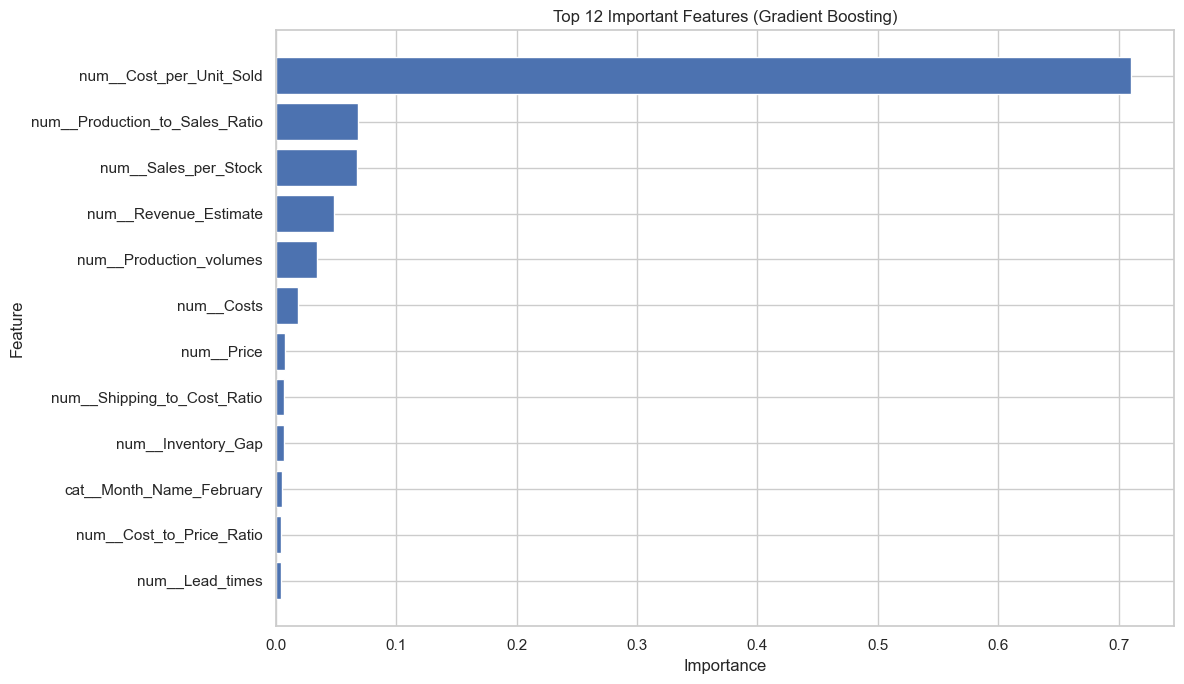

In [81]:
top_n = 12
top_features = feature_importance_df.head(top_n).sort_values("Importance")

plt.figure(figsize=(12, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title(f"Top {top_n} Important Features ({best_model_name})")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Insight:**  
Feature importance analysis shows that Cost per Unit Sold is the most dominant factor, significantly influencing demand predictions compared to other features.
Other features like production-to-sales ratio, sales per stock, and revenue estimate also contribute, but with much lower impact, indicating the model relies heavily on cost-related dynamics.

### Step 13 — Forecast Example

#### Objective
To demonstrate how the selected model can be used for near-term demand prediction on the most recent operational records.

#### Purpose
This step shows the notebook’s practical value. Instead of stopping at model training, it turns the best model into a usable forecasting asset for decision support.

In [82]:
forecast_input = X.tail(5).copy()
forecast_dates = ml_df["Date"].tail(5).reset_index(drop=True)

forecast_values = best_model.predict(forecast_input)

forecast_df = pd.DataFrame({
    "Date": forecast_dates,
    "Forecasted_HistoricalSales": forecast_values
})

forecast_df

,Date,Forecasted_HistoricalSales
0,2023-07-10,572.50
1,2023-07-12,486.78
2,2023-07-14,94.89
3,2023-07-16,761.15
4,2023-07-18,705.02


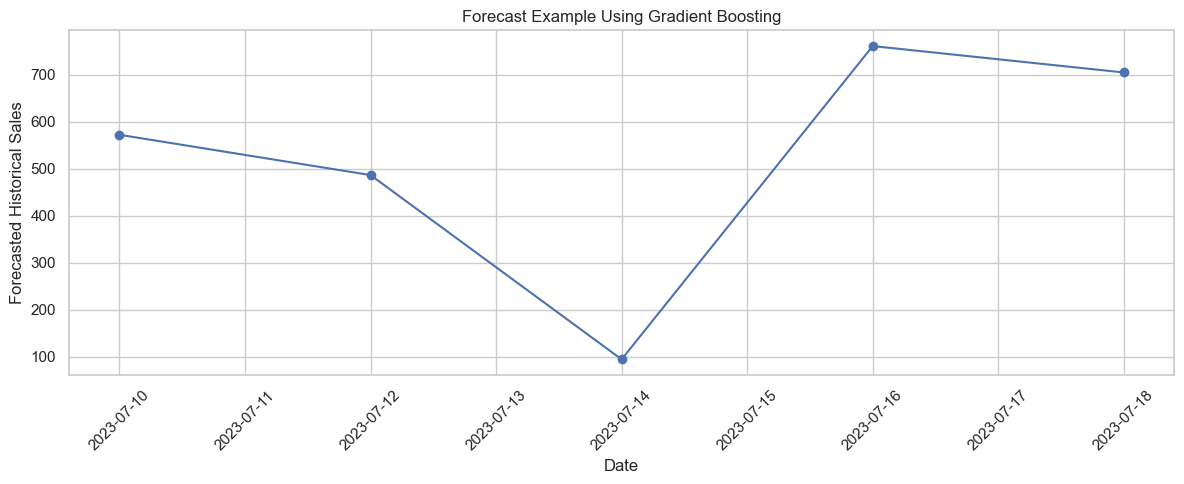

In [83]:
plt.figure(figsize=(12, 5))
plt.plot(forecast_df["Date"], forecast_df["Forecasted_HistoricalSales"], marker="o")
plt.title(f"Forecast Example Using {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Forecasted Historical Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Forecast Insight:**  
The forecast indicates fluctuating demand with a sharp dip followed by a strong recovery, suggesting short-term volatility in sales patterns.
This highlights the need for flexible inventory and supply planning to quickly adapt to sudden changes in demand.

 ### Save the Best Model

In [84]:
joblib.dump(best_model, "supply_chain_model.pkl")
print("Model saved as supply_chain_model.pkl")

Model saved as supply_chain_model.pkl


# Final Business Insights

1. Supply chain demand shows significant fluctuations over time, indicating that dynamic and adaptive planning is essential.

2. Supplier and location performance are uneven, with revenue and risk concentrated in specific segments, requiring targeted strategies.

3. Key operational factors such as transportation mode, inspection quality, manufacturing cost, and inventory structure strongly influence business performance.

4. Machine learning models, especially for predicting historical sales, provide high accuracy and can effectively support demand planning.

5. High-impact features identified by the model should be continuously monitored to enable proactive and data-driven decision-making.

# Project Limitations

- The dataset size is relatively limited after preprocessing, which may affect model robustness and scalability.

- Important external factors like holidays, economic conditions, and competitor actions are not included in the analysis.

- The current model is based on available operational data; a longer time-series dataset could improve forecasting performance.

- Real-world deployment would require regular model retraining and monitoring to handle changing demand patterns.

# Conclusion

This project delivers a comprehensive Supply Chain Analysis and Demand Forecasting solution, covering the full workflow from data preprocessing to advanced machine learning modeling. It integrates data cleaning, feature engineering, visualization, model evaluation, and forecasting into a structured and business-focused approach.

Overall, the project demonstrates how data analytics and machine learning can enhance supply chain efficiency, improve demand prediction, and support strategic decision-making in real-world scenarios.